#### Setting up the environment
The first step is to set up the conda environment. You should use the `profsea-env.yml` environment file, building it with 

```bash
conda env create -f profsea-env.yml
```

and then activating with `conda activate profsea`.

---

One final step here is to install ProFSea as an editable package, using

```bash 
pip install -e . 
```

while inside the highest level directory.

#### Importing components

The next step is to import all the model components you want to run simulations with - a full list is available in the documention [here](https://metoffice.github.io/ProFSea-tool/). This can be any combination of available `global` and `spatial` components, how you build your model is up to you!

To generate a comprehensive set of sea-level projections, we'll run with all the components that contribute to sea-level change: 
- thermal expansion
- glaciers
- greenland ice-sheet
- antarctic ice-sheet
- landwater 

In the example below, we'll run with the configuration being used for SLEIP and Munday et al. (2026), *in prep*.

In [1]:
from profsea.components.core.global_model import Global
from profsea.components.global_ import (
    AntarcticaISMIP6,
    Glacier,
    GreenlandAR6,
    LandwaterAR6,
    ThermalExpansion,
)

`ProFSea` can run with a single or an ensemble of temperature and ocean heat content forcing trajectories. The trajectories need to be anomalies, relative to some baseline period - `ProFSea` assumes by default this is `1996-2014`

Here we'll just run with an idealised temperature ramp up and stabilisation, and corresponding ocean heat content change, running from `2006` to `2300`:

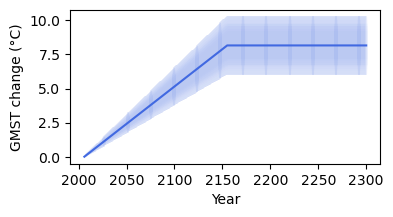

In [2]:
import matplotlib.pyplot as plt
import numpy as np

t_change = np.concatenate([np.linspace(0.01, 8, 150), np.linspace(8, 8, 145)])
t_change = t_change[None, :] * np.random.normal(
    loc=1.0, scale=0.1, size=(100, 1)
)  # add some variability across members
ohc_change = t_change * 1e24  # in Joules
years = np.arange(2006, 2301)
years = np.broadcast_to(years, t_change.shape)

plt.figure(figsize=(4, 2))
plt.plot(years, t_change, color="royalblue", alpha=0.1)
plt.plot(
    years.mean(axis=0), t_change.mean(axis=0), color="royalblue", label="GMST change"
)
plt.xlabel("Year")
plt.ylabel("GMST change (°C)")
plt.show()
plt.close()

#### Building the model

To build your model, simply add your components to a dictionary, with whatever names you like, and pass it to the `Global()` class

In [3]:
global_components = {
    "landwater": LandwaterAR6(),
    "greenland": GreenlandAR6(),
    "expansion": ThermalExpansion(
        ohc_change
    ),  # only the thermal expansion needs OHC change, so we'll pass it in here
    "wais": AntarcticaISMIP6(ais_region="wais"),
    "eais": AntarcticaISMIP6(ais_region="eais"),
    "peninsula": AntarcticaISMIP6(ais_region="peninsula"),
    "glacier": Glacier(),
}
global_model = Global(components=global_components, end_yr=2301, num_members=1000)

now we're ready to run our simulation...

In [4]:
projections = global_model.run(
    T_change=t_change, scenario="stabilisation", member_seed=42
)
global_model.sum_components(projections)
gmslr = global_model.results["total_gmslr"]

╭──────────────────────── ProFSea Global Run Configuration ─────────────────────────╮
│        Scenario  stabilisation                                                    │
│      Components  landwater, greenland, expansion, wais, eais, peninsula, glacier  │
│       Timeframe  2006 -> 2301                                                     │
│   Ensemble Size  100 inputs × 1000 draws (= 100000)                               │
│          Output  Full Distribution (100000 members)                               │
│  Compute Engine  Parallel Threading                                               │
╰───────────────────────────────────────────────────────────────────────────────────╯

visualise the global simulations!

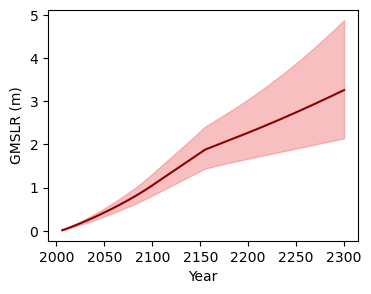

In [5]:
plt.figure(figsize=(4, 3))
lower = np.percentile(gmslr, 5, axis=0)
upper = np.percentile(gmslr, 95, axis=0)
plt.fill_between(
    years[0], lower, upper, color="lightcoral", alpha=0.5, label="90% range"
)
plt.plot(years[0], gmslr.mean(axis=0), color="darkred")
plt.xlabel("Year")
plt.ylabel("GMSLR (m)")
plt.show()
plt.close()

#### Building the `Spatial` model

Start with the imports:

In [6]:
from profsea.components.core import Spatial
from profsea.components.spatial import (
    GIA,
    Fingerprint,
    SterodynamicCMIP6,
)

Now we'll build the model in the same way as the global model, but we'll pass the individual components' global projections to each spatial module. 

In [7]:
spatial_components = {
    "sterodynamic": SterodynamicCMIP6(
        projections["expansion"],  # passing in the global thermal expansion projection
    ),
    "greenland": Fingerprint(
        projections["greenland"], fingerprint_component="greenland"
    ),
    "landwater": Fingerprint(
        projections["landwater"],
        fingerprint_component="landwater",
    ),
    "wais": Fingerprint(
        projections["wais"],
        fingerprint_component="wais",
    ),
    "eais": Fingerprint(
        projections["eais"],
        fingerprint_component="eais",
    ),
    "glacier": Fingerprint(
        projections["glacier"],
        fingerprint_component="glacier",
    ),
    "gia": GIA(
        sample_spatial=False,
    ),
}

# Pass to the spatial model
spatial_model = Spatial(components=spatial_components)
spatial_model.run(member_seed=42)

total_rsl = spatial_model.sum_components(spatial_model.results)

[14:29:54] ✓ ProFSea assets found locally!                                                             ]8;id=3664210;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py\utils.py]8;;\:]8;id=3664211;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py#188\188]8;;\

[14:29:54] INFO     Baseline period = 1995 to 2014

╭─────────────────────── ProFSea Spatial Run Configuration ────────────────────────╮
│        Components  sterodynamic, greenland, landwater, wais, eais, glacier, gia  │
│         Timeframe  2006 -> 2301                                                  │
│          Baseline  1995 - 2014                                                   │
│   Grid Resolution  180 × 360 cells                                               │
│            Output  Percentiles: [5, 17, 50, 83, 95]                              │
│  Est. Output Size  ~0.76 GB                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

           INFO     Simulating 7 sea-level components: sterodynamic, greenland, landwater, wais, eais, glacier, gia

Saving the spatial projections is easy + quick using Zarr format: 

In [8]:
spatial_model.save_components(
    spatial_model.results, scenario_name="stabilisation", output_format="zarr"
)

[14:30:10] ✓ Successfully saved Zarr: ./stabilisation_projection.zarr                                  ]8;id=3664217;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py\utils.py]8;;\:]8;id=3664218;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py#322\322]8;;\

           Output shape was (5, 295, 180, 360) (percentile, time, lat, lon)                            ]8;id=3664224;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py\utils.py]8;;\:]8;id=3664225;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py#325\325]8;;\

Plot the output! This takes about 90 seconds, since our data goes from lazy &rarr; in memory

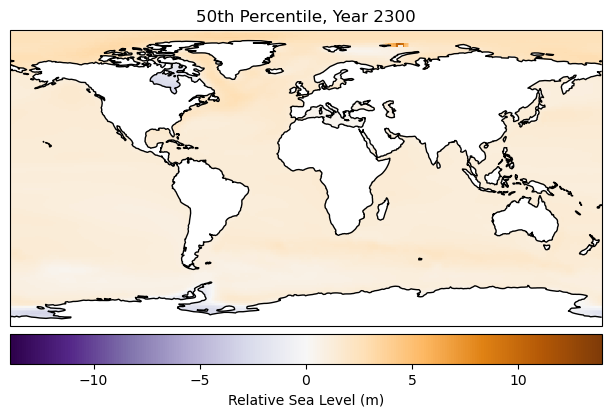

In [9]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(6, 4), layout="constrained")

total_rsl_med = total_rsl[2, -1, :, :]
vmax = np.nanmax(np.abs(total_rsl))
vmin = -vmax

ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_title("50th Percentile, Year 2300")
ax.pcolormesh(
    spatial_model.grid_lons,
    spatial_model.grid_lats,
    total_rsl_med,
    transform=ccrs.PlateCarree(),
    cmap="PuOr_r",
    vmin=vmin,
    vmax=vmax,
)
ax.coastlines()
fig.colorbar(
    mappable=ax.collections[0],
    label="Relative Sea Level (m)",
    orientation="horizontal",
    pad=0.02,
)
plt.show()

Next, we'll drill down on a few grid-boxes of interest. To do this we can use the `Local` model.

We give the spatial components to our `Local` model, and a dictionary of locations with associated lat/lons: 

In [10]:
from profsea.components.core.local_model import Local

from profsea.components.core import Spatial
from profsea.components.spatial import (
    SterodynamicCMIP6,
    Fingerprint,
    GIA,
)

locations = {
    "Aberdeen": (57.144, -2.080),
    "Holyhead": (53.314, -4.620),
    "Llandudno": (53.330, -3.830),
    "Land point": (-34.6037, -58.3816),
}

local_components = {
    "sterodynamic": SterodynamicCMIP6(
        projections["expansion"],  # passing in the global thermal expansion projection
    ),
    "greenland": Fingerprint(
        projections["greenland"], 
        fingerprint_component="greenland"
    ),
    "landwater": Fingerprint(
        projections["landwater"],
        fingerprint_component="landwater",
    ),
    "wais": Fingerprint(
        projections["wais"],
        fingerprint_component="wais",
    ),
    "eais": Fingerprint(
        projections["eais"],
        fingerprint_component="eais",
    ),
    "glacier": Fingerprint(
        projections["glacier"],
        fingerprint_component="glacier",
    ),
    "gia": GIA(
        sample_spatial=False,
    ),
}

local_model = Local(components=local_components, locations=locations)
local_timeseries = local_model.run(member_seed=42)
total_rsl = local_model.sum_components(local_model.results)

[14:30:23] ✓ ProFSea assets found locally!                                                             ]8;id=3664230;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py\utils.py]8;;\:]8;id=3664231;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py#188\188]8;;\

[14:30:23] INFO     Baseline period = 1995 to 2014

           INFO     Configured for 4 specific target locations.

           INFO     Simulating 7 sea-level components for 4 sites...

[14:30:27] WARNING  The following site(s) may be over land: Land point. Expect NaN values for all components.      
                    Either try increasing your grid resolution or check your site coordinates.

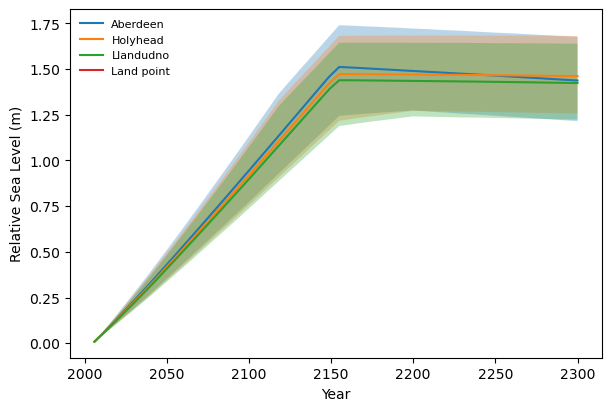

In [11]:
loc_ts = local_timeseries["total_rsl"].sel(site=["Aberdeen", "Holyhead", "Llandudno", "Land point"], percentile=[17, 50, 83])
fig = plt.figure(figsize=(6, 4), layout="constrained")
ax = fig.add_subplot(111)
for loc in loc_ts.site.values:
    loc_data = loc_ts.sel(site=loc)
    ax.fill_between(loc_data.time, loc_data.sel(percentile=17), loc_data.sel(percentile=83), alpha=0.3)
    ax.plot(loc_data.time, loc_data.sel(percentile=50), label=loc)
ax.set_xlabel("Year")
ax.set_ylabel("Relative Sea Level (m)")
ax.legend(frameon=False, loc="upper left", fontsize=8)

plt.show()